# 🥑 Avocado Data Analysis & Machine Learning Project

## 📌 Introduction

Avocados (Avocado) have become one of the most popular agricultural products globally, driven by increasing awareness of their nutritional benefits and rising demand in modern diets. As consumption continues to grow, understanding the factors that influence avocado pricing and classification has become essential for producers, retailers, and data analysts.

This project focuses on exploring and analyzing avocado sales data to uncover meaningful patterns and build predictive models. The dataset includes information on avocado prices, sales volume, product types (organic and conventional), and distribution across different regions and time periods.

The analysis is divided into key components. First, a regression approach is used to investigate how various factors, particularly sales volume, influence the average price of avocados. This helps in understanding the economic relationship between supply and pricing. Next, a classification model is developed to distinguish between organic and conventional avocados using machine learning techniques such as Logistic Regression.

Additionally, the project explores the potential of time-based analysis to study trends and patterns in avocado prices over time, offering insights into seasonality and market behavior.

By combining data cleaning, exploratory data analysis, and machine learning techniques, this project demonstrates how data-driven approaches can be applied to real-world agricultural and economic problems.

In [172]:
# import libraries
import pandas as pd
import numpy as np
import janitor
import seaborn as sns
from ipywidgets import interact
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from plotnine import *

In [173]:
# load your dataset
avocado = pd.read_csv("C:/Users/user/Downloads/avocado.csv")
avocado.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,12/27/2015,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,12/20/2015,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,12/13/2015,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,12/6/2015,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,11/29/2015,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


# Part 2: Avocado Type Classification 
Objective: Classify avocados as Organic or Conventional using  Logistic Regression or PCA 

# Data cleaning

In [174]:
# data info 
avocado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  object 
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  object 
 12  year          18249 non-null  int64  
 13  region        18249 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 1.9+ MB


In [175]:
# fixing the column names
avocado2 = avocado.clean_names()
avocado2.head()

,unnamed_0,date,averageprice,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region
0,0,12/27/2015,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,12/20/2015,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,12/13/2015,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,12/6/2015,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,11/29/2015,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [176]:
# remove column unnamed

avocado2 = avocado2.drop(columns = ["unnamed_0"])
avocado2.head()

,date,averageprice,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region
0,12/27/2015,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,12/20/2015,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,12/13/2015,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,12/6/2015,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,11/29/2015,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [177]:
# fixing average price column
avocado2. rename(columns = {"averageprice" : "average_price"}, inplace = True)
avocado2.head()

,date,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region
0,12/27/2015,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,12/20/2015,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,12/13/2015,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,12/6/2015,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,11/29/2015,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [178]:
# Convert Date column to datetime format
avocado2["date"] = pd.to_datetime(avocado2["date"])
avocado2.head()

,date,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [179]:
# checking missing values
avocado2.isnull().sum()

date             0
average_price    0
total_volume     0
4046             0
4225             0
4770             0
total_bags       0
small_bags       0
large_bags       0
xlarge_bags      0
type             0
year             0
region           0
dtype: int64

In [180]:
# checking for duplicates
avocado2.duplicated().sum()

np.int64(0)

In [181]:
# Extract features such as month and year 
avocado2["month"] = avocado2["date"].dt.month
avocado2.head()

,date,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region,month
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany,12
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany,12
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany,12
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany,12
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany,11


In [182]:
# data describ

avocado2.describe()

,date,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,year,month
count,18249,18249.000000,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000,18249.000000,18249.000000
mean,2016-08-13 23:30:43.498273792,1.405978,8.506440e+05,2.930084e+05,2.951546e+05,2.283974e+04,2.396392e+05,1.821947e+05,5.433809e+04,3106.426507,2016.147899,6.177215
min,2015-01-04 00:00:00,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2015.000000,1.000000
25%,2015-10-25 00:00:00,1.100000,1.083858e+04,8.540700e+02,3.008780e+03,0.000000e+00,5.088640e+03,2.849420e+03,1.274700e+02,0.000000,2015.000000,3.000000
50%,2016-08-14 00:00:00,1.370000,1.073768e+05,8.645300e+03,2.906102e+04,1.849900e+02,3.974383e+04,2.636282e+04,2.647710e+03,0.000000,2016.000000,6.000000
75%,2017-06-04 00:00:00,1.660000,4.329623e+05,1.110202e+05,1.502069e+05,6.243420e+03,1.107834e+05,8.333767e+04,2.202925e+04,132.500000,2017.000000,9.000000
max,2018-03-25 00:00:00,3.250000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,2018.000000,12.000000
std,NaN,0.402677,3.453545e+06,1.264989e+06,1.204120e+06,1.074641e+05,9.862424e+05,7.461785e+05,2.439660e+05,17692.894652,0.939938,3.534130


In [183]:
avocado2.skew(numeric_only = True)

average_price     0.580303
total_volume      9.007687
4046              8.648220
4225              8.942466
4770             10.159396
total_bags        9.756072
small_bags        9.540660
large_bags        9.796455
xlarge_bags      13.139751
year              0.215339
month             0.106617
dtype: float64

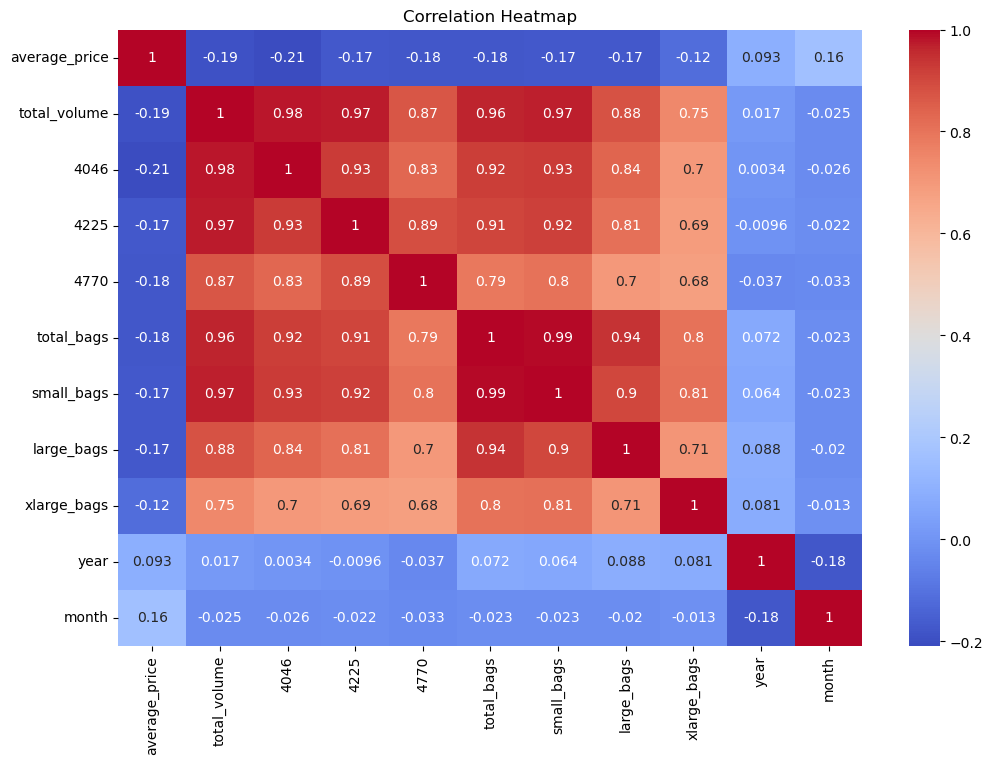

In [184]:
plt.figure(figsize=(12,8))
sns.heatmap(avocado2.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# interpretation 
The correlation heatmap shows that avocado price has a weak negative relationship with most numerical variables such as total volume and bag counts. This suggests that increases in supply slightly reduce price, although the relationship is not strong.

Additionally, there is a very high positive correlation among volume-related variables (e.g., total volume, PLU codes, and bag sizes), indicating multicollinearity. This means many features contain similar information, which can negatively affect regression model performance.

In [185]:
avocado2.shape

(18249, 14)

In [186]:
avocado2['type'] = avocado['type'].map({'organic': 1, 'conventional': 0})
avocado2.head()

,date,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region,month
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,0,2015,Albany,12
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,0,2015,Albany,12
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,0,2015,Albany,12
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,0,2015,Albany,12
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,0,2015,Albany,11


# Data Preprocessing

In [187]:
# selecting relevant features 
avocado2 = avocado2.drop(["small_bags", "large_bags", "xlarge_bags", "date", "region"], axis = 1)
avocado2.head()

,average_price,total_volume,4046,4225,4770,total_bags,type,year,month
0,1.33,64236.62,1036.74,54454.85,48.16,8696.87,0,2015,12
1,1.35,54876.98,674.28,44638.81,58.33,9505.56,0,2015,12
2,0.93,118220.22,794.70,109149.67,130.50,8145.35,0,2015,12
3,1.08,78992.15,1132.00,71976.41,72.58,5811.16,0,2015,12
4,1.28,51039.60,941.48,43838.39,75.78,6183.95,0,2015,11


In [188]:
avocado2.shape

(18249, 9)

# Data spliting

In [189]:
from sklearn.model_selection import train_test_split

In [190]:
#independent_variables

x = avocado2.drop("type", axis = 1)
x.head()

,average_price,total_volume,4046,4225,4770,total_bags,year,month
0,1.33,64236.62,1036.74,54454.85,48.16,8696.87,2015,12
1,1.35,54876.98,674.28,44638.81,58.33,9505.56,2015,12
2,0.93,118220.22,794.70,109149.67,130.50,8145.35,2015,12
3,1.08,78992.15,1132.00,71976.41,72.58,5811.16,2015,12
4,1.28,51039.60,941.48,43838.39,75.78,6183.95,2015,11


In [191]:
# dependent_variables

y = avocado2["type"]
y.head()

0    0
1    0
2    0
3    0
4    0
Name: type, dtype: int64

In [192]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [193]:
x_train.shape

(14599, 8)

In [194]:
x_test.shape

(3650, 8)

# Initiate and train the model

In [195]:
from sklearn.linear_model import LogisticRegression

class_model = LogisticRegression()
class_model.fit(x_train, y_train)

C:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


LogisticRegression()

In [196]:
class_model.intercept_

array([1.338804e-05])

In [197]:
class_model.coef_

array([[ 0.04285349,  0.12663118, -0.12666686, -0.12665541, -0.12695356,
        -0.12661964,  0.00132386, -0.06931022]])

# Preprocess: Standardization

In [198]:
from sklearn.preprocessing import StandardScaler

sca = StandardScaler()

x_train_scaled = sca.fit_transform(x_train)

x_train_scaled


x_scaled_avocado = pd.DataFrame(x_train_scaled, columns = x_train.columns)
x_scaled_avocado.head()

,average_price,total_volume,4046,4225,4770,total_bags,year,month
0,1.178674,-0.247683,-0.235928,-0.245519,-0.211662,-0.241649,0.905234,1.360639
1,-1.475662,-0.079312,-0.110923,-0.118244,-0.011670,0.010839,-0.158217,-1.471649
2,1.501164,-0.247362,-0.234417,-0.244132,-0.211662,-0.244176,-0.158217,1.360639
3,-0.954717,-0.206482,-0.173141,-0.213823,-0.210415,-0.216627,-1.221669,-1.188420
4,0.310433,-0.237356,-0.235916,-0.213896,-0.211662,-0.244402,-0.158217,-0.055505


In [199]:
class_model2 = LogisticRegression()

class_model2.fit(x_scaled_avocado, y_train)

LogisticRegression()

# Model Result

In [200]:
class_model2.intercept_

array([-8.11189458])

In [201]:
class_model2.coef_

array([[  1.80898302,  -8.52602351, -14.23337784, -14.36688088,
        -12.04942485,   7.37398315,  -0.3188103 ,  -0.4484158 ]])

In [202]:
lr = pd.DataFrame(class_model2.coef_.T, x_scaled_avocado.columns, columns = ["Coefficient"])

lr

,Coefficient
average_price,1.808983
total_volume,-8.526024
4046,-14.233378
4225,-14.366881
4770,-12.049425
total_bags,7.373983
year,-0.318810
month,-0.448416


In [203]:
import numpy as np
lr = pd.DataFrame(np.exp(class_model2.coef_), columns =  x_scaled_avocado.columns)

lr

,average_price,total_volume,4046,4225,4770,total_bags,year,month
0,6.104236,0.000198,6.584496e-07,5.761597e-07,0.000006,1593.970172,0.727013,0.638639


# Model Evaluation

In [204]:
class_pred = class_model2.predict(x_scaled_avocado)

In [205]:
from sklearn import metrics

print(metrics.classification_report(y_train, class_pred))

              precision    recall  f1-score   support

           0       0.94      0.90      0.92      7306
           1       0.90      0.94      0.92      7293

    accuracy                           0.92     14599
   macro avg       0.92      0.92      0.92     14599
weighted avg       0.92      0.92      0.92     14599



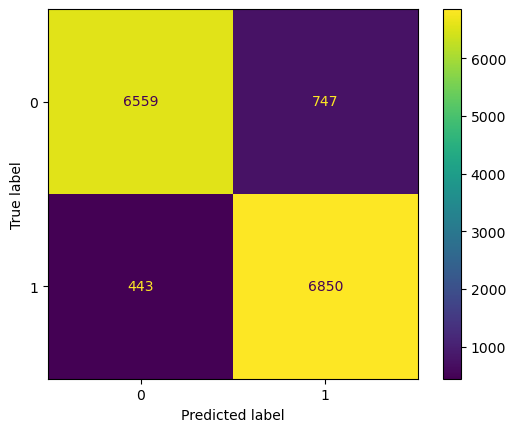

In [206]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pylab as plt

ConfusionMatrixDisplay.from_predictions(y_train, class_pred)

In [207]:
x_avocado =avocado2.drop("type", axis = 1)
y_avocado = avocado2["type"]

In [208]:
import statsmodels.api as sm

X_sm = sm.add_constant(x_avocado)

model_train = sm.Logit(y_avocado, X_sm).fit_regularized(L1_wt=1, alpha=0.1, maxiter=1000) #Lasso regularization

print(model_train.summary())

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log


Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.19922415331796117
            Iterations: 134
            Function evaluations: 173
            Gradient evaluations: 134
                           Logit Regression Results                           
Dep. Variable:                   type   No. Observations:                18249
Model:                          Logit   Df Residuals:                    18240
Method:                           MLE   Df Model:                            8
Date:                Mon, 20 Apr 2026   Pseudo R-squ.:                  0.7181
Time:                        01:38:30   Log-Likelihood:                -3566.3
converged:                       True   LL-Null:                       -12649.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 5 out of 9 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp


# 🔍 Model Performance

The Logistic Regression model achieved an accuracy of approximately 92%, indicating that the model correctly classifies avocado types (organic vs conventional) with high accuracy.

The precision, recall, and F1-scores for both classes are high and balanced:
	•	Class 0 (e.g., Conventional)
	•	Class 1 (e.g., Organic)

👉 This shows the model performs well for both avocado types without bias.

⸻

# 🔲 Confusion Matrix Interpretation

The confusion matrix shows that most predictions fall along the diagonal, indicating correct classification.

	•	A large number of conventional avocados were correctly classified
	•	A large number of organic avocados were correctly classified
	•	Misclassifications are relatively small

👉 This confirms that the model can effectively distinguish between avocado types

# 📌 Final Conclusion

In this notebook, Logistic Regression was used to classify avocado types into organic and conventional categories. The model achieved an accuracy of approximately 92%, indicating strong predictive performance.

The evaluation metrics, including precision, recall, and F1-score, show that the model performs consistently across both classes. The confusion matrix further confirms that most observations are correctly classified, with only a small number of misclassifications.

These results suggest that the selected features, such as total volume and region, provide sufficient information to distinguish between avocado types.

In conclusion, Logistic Regression proves to be an effective model for classifying avocado types and demonstrates the usefulness of classification techniques in identifying patterns within the dataset

# classification with PAC

In [209]:
avocado3 = avocado.copy()

In [210]:
avocado3.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,12/27/2015,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,12/20/2015,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,12/13/2015,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,12/6/2015,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,11/29/2015,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


# data cleaning

In [211]:
# fixing the column names
avocado3 = avocado.clean_names()
avocado3.head()

,unnamed_0,date,averageprice,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region
0,0,12/27/2015,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,12/20/2015,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,12/13/2015,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,12/6/2015,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,11/29/2015,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [212]:
# remove column unnamed

avocado3 = avocado3.drop(columns = ["unnamed_0"])
avocado3.head()

,date,averageprice,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region
0,12/27/2015,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,12/20/2015,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,12/13/2015,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,12/6/2015,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,11/29/2015,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [213]:
# Convert Date column to datetime format
avocado3["date"] = pd.to_datetime(avocado3["date"])
avocado3.head()

,date,averageprice,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [214]:
# fixing average price column
avocado3. rename(columns = {"averageprice" : "average_price"}, inplace = True)
avocado3.head()

,date,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [215]:
# Extract features such as month and year 
avocado3["month"] = avocado3["date"].dt.month
avocado3.head()

,date,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region,month
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany,12
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany,12
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany,12
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany,12
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany,11


In [216]:
# checking missing values
avocado3.isnull().sum()

date             0
average_price    0
total_volume     0
4046             0
4225             0
4770             0
total_bags       0
small_bags       0
large_bags       0
xlarge_bags      0
type             0
year             0
region           0
month            0
dtype: int64

In [217]:
# checking for duplicates
avocado3.duplicated().sum()

np.int64(0)

# Data Preprocessing

In [218]:
avocado3['type'] = avocado['type'].map({'organic': 1, 'conventional': 0})
avocado3.head()

,date,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region,month
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,0,2015,Albany,12
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,0,2015,Albany,12
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,0,2015,Albany,12
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,0,2015,Albany,12
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,0,2015,Albany,11


In [219]:
avocado_3 = avocado3.drop(["type", "region", "date"], axis = 1) 
avocado_3.head()

,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,year,month
0,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,2015,12
1,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,2015,12
2,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,2015,12
3,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,2015,12
4,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,2015,11


# Standardization Of The Dataset

In [220]:
from sklearn.preprocessing import StandardScaler

avocado_sca = StandardScaler()
avocado_scaled = avocado_sca.fit_transform(avocado_3)
avocado_scaled

#avocado_scaled_df = pd.DataFrame(avocado_scaled, columns = avocado_3.columns)
#avocado_scaled_df.head()

array([[-0.18868864, -0.22771641, -0.23081597, ..., -0.17557961,
        -1.22128204,  1.64763162],
       [-0.13901962, -0.23042664, -0.23110251, ..., -0.17557961,
        -1.22128204,  1.64763162],
       [-1.18206895, -0.21208462, -0.23100731, ..., -0.17557961,
        -1.22128204,  1.64763162],
       ...,
       [ 1.15237477, -0.24233073, -0.2306933 , ..., -0.17557961,
         1.97050371, -1.46495942],
       [ 1.30138182, -0.24162464, -0.2304279 , ..., -0.17557961,
         1.97050371, -1.46495942],
       [ 0.53151208, -0.24125273, -0.22934712, ..., -0.17557961,
         1.97050371, -1.46495942]])

# Application of the pca

In [221]:
from sklearn.decomposition import PCA
pca= PCA()
pca.fit(avocado_scaled)

PCA()

In [222]:
avocado_pca = pca.transform(avocado_scaled)
print(avocado_scaled.shape)
print(avocado_pca.shape)

(18249, 11)
(18249, 11)


# Extract explained variance

The explained_variance_ratio_ attribute returns the percentage of variance explained by each of the selected components.

In [223]:
# Get the percentage of variance explained by each component
explained_variance = pca.explained_variance_ratio_

In [224]:
explained_variance

array([6.39591174e-01, 1.08234019e-01, 9.92281048e-02, 6.42142574e-02,
       3.67832783e-02, 2.99306127e-02, 1.18875581e-02, 6.12511552e-03,
       4.00588084e-03, 1.43476401e-11, 1.81639165e-16])

In [225]:
len(pca.explained_variance_ratio_)

11

# scale plot

In [226]:
explained_variance_df = pd.DataFrame({"values": range(1, 12),
             "explained_variance": explained_variance})

explained_variance_df.head()

,values,explained_variance
0,1,0.639591
1,2,0.108234
2,3,0.099228
3,4,0.064214
4,5,0.036783


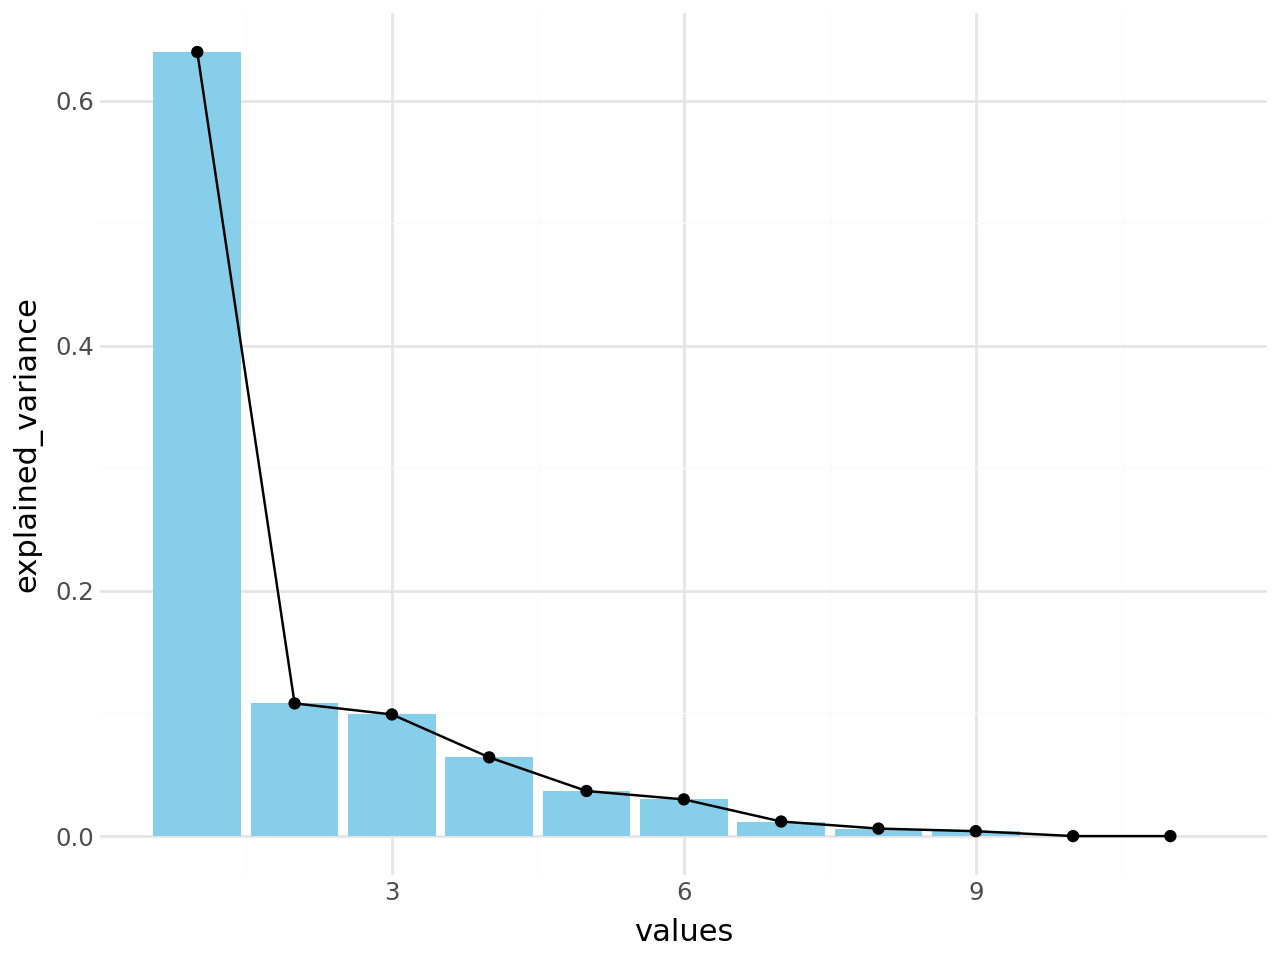

In [227]:
(ggplot(explained_variance_df, aes("values", "explained_variance"))
+ geom_col(fill = "skyblue")
+ geom_line()
+ geom_point()
+ theme_minimal())

# Inspection of the Pca Components

In [228]:
loadings = pd.DataFrame(pca.components_.T, columns = [f'PC{i+1}' for i in range(len(avocado_3.columns))], index = avocado_3.columns)
print(loadings)

                    PC1       PC2       PC3       PC4       PC5       PC6  \
average_price -0.081972  0.225798  0.769145 -0.589534 -0.017886 -0.043274   
total_volume   0.373181  0.026713 -0.002755 -0.037867 -0.170897 -0.046750   
4046           0.360419  0.028463 -0.030304 -0.031762 -0.227299 -0.083332   
4225           0.359234  0.048704 -0.017156 -0.086433 -0.321429  0.098469   
4770           0.330921  0.053846 -0.058356 -0.124053 -0.333533  0.611175   
total_bags     0.369838 -0.008296  0.056523  0.027183  0.121892 -0.243637   
small_bags     0.369442 -0.002163  0.051105  0.011893  0.093847 -0.153696   
large_bags     0.342862 -0.025779  0.064318  0.070860  0.148737 -0.547885   
xlarge_bags    0.307118 -0.015731  0.108543  0.036593  0.785698  0.455779   
year           0.015234 -0.617235  0.566599  0.498414 -0.190739  0.112258   
month         -0.013483  0.748503  0.247043  0.609500 -0.068984  0.047653   

                    PC7       PC8       PC9          PC10          PC11  
a

In [229]:
top_pc1 = loadings['PC1'].abs().sort_values(ascending=False).head(5)
print(top_pc1)

total_volume    0.373181
total_bags      0.369838
small_bags      0.369442
4046            0.360419
4225            0.359234
Name: PC1, dtype: float64


# Three PCA Components

In [230]:
from sklearn.decomposition import PCA
pca_3 = PCA(n_components = 3)
pca_3.fit(avocado_scaled)

PCA(n_components=3)

In [231]:
avocado_pca2 = pca_3.transform(avocado_scaled)
avocado_pca2

array([[-0.63823475,  1.92160007, -0.46512607],
       [-0.64561062,  1.93233313, -0.42667034],
       [-0.53494024,  1.69996817, -1.23010828],
       ...,
       [-0.67584245, -2.07760664,  1.60635085],
       [-0.68616513, -2.04393251,  1.72114156],
       [-0.62337573, -2.21801292,  1.12937484]])

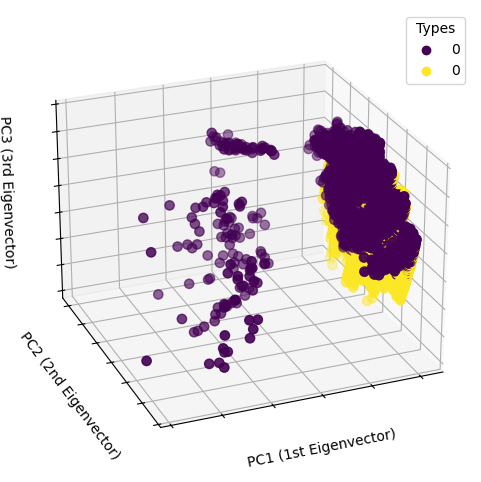

In [232]:
import matplotlib.pyplot as plt

fig = plt.figure(1, figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d", elev=-155, azim=112)
# scatter plot of eigen vectors
sctr = ax.scatter(avocado_pca2[:, 0], avocado_pca2[:, 1], avocado_pca2[:, 2],
           c = avocado3.type, s=45,)
ax.legend(sctr.legend_elements()[0], avocado3.type,
          loc="upper right", title="Types")

ax.set_xlabel("PC1 (1st Eigenvector)")
ax.xaxis.set_ticklabels([])
ax.set_ylabel("PC2 (2nd Eigenvector)")
ax.yaxis.set_ticklabels([])
ax.set_zlabel("PC3 (3rd Eigenvector)")
ax.zaxis.set_ticklabels([])

plt.show()

# Training Logistic Regression with PCA

In [233]:
x = avocado_3
x.head()

,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,year,month
0,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,2015,12
1,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,2015,12
2,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,2015,12
3,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,2015,12
4,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,2015,11


In [234]:
y = avocado3["type"]
y.head()

0    0
1    0
2    0
3    0
4    0
Name: type, dtype: int64

# Spliiting Of the Dataset 


In [235]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [236]:
from sklearn.preprocessing import StandardScaler

sca2 = StandardScaler()
x_train_scaled = sca2.fit(x_train)

x_train_transform = x_train_scaled.transform(x_train)

x_train_transform_df = pd.DataFrame(x_train_transform, columns = x_train.columns)
x_train_transform_df.head()

,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,year,month
0,1.178674,-0.247683,-0.235928,-0.245519,-0.211662,-0.241649,-0.241658,-0.224957,-0.177018,0.905234,1.360639
1,-1.475662,-0.079312,-0.110923,-0.118244,-0.011670,0.010839,-0.049399,0.206852,-0.177018,-0.158217,-1.471649
2,1.501164,-0.247362,-0.234417,-0.244132,-0.211662,-0.244176,-0.245084,-0.224710,-0.177018,-0.158217,1.360639
3,-0.954717,-0.206482,-0.173141,-0.213823,-0.210415,-0.216627,-0.212047,-0.214273,-0.177018,-1.221669,-1.188420
4,0.310433,-0.237356,-0.235916,-0.213896,-0.211662,-0.244402,-0.245293,-0.224985,-0.177018,-0.158217,-0.055505


In [237]:
from sklearn.decomposition import PCA

pca_2 = PCA(n_components = 3)
pca_2.fit(x_train_transform_df)

x_train_pca = pca_2.transform(x_train_transform_df)

x_train_pca.shape

x_train_pca_df = pd.DataFrame({"pca_1" : x_train_pca[:, 0],
                               "pca_2" : x_train_pca[:, 1],
                               "pca_3" : x_train_pca[:, 2]
                              })
x_train_pca_df.head()

,pca_1,pca_2,pca_3
0,-0.745923,0.656654,1.737376
1,0.022379,-1.307463,-1.625852
2,-0.787836,1.393720,1.403709
3,-0.496782,-0.324896,-1.763597
4,-0.660203,0.100965,0.101957


In [238]:
from sklearn.linear_model import LogisticRegression

avocado_model2 = LogisticRegression()
avocado_model2.fit(x_train_pca_df[["pca_1", "pca_2", "pca_3"]], y_train)

LogisticRegression()

In [239]:
avocado_model2.intercept_

array([-6.14736956])

In [240]:
avocado_model2.coef_

array([[-12.02550496,  -0.38593253,   0.36258684]])

# Model Evaluation

In [241]:
class_pred = avocado_model2.predict(x_train_pca_df[["pca_1", "pca_2", "pca_3"]])
class_pred

array([1, 0, 1, ..., 1, 0, 1])

In [242]:
from sklearn import metrics
print("\n Classification report for classifier %s:\n%s\n"
      % (avocado_model2, metrics.classification_report(y_train, class_pred)))


 Classification report for classifier LogisticRegression():
              precision    recall  f1-score   support

           0       0.93      0.87      0.90      7306
           1       0.88      0.93      0.90      7293

    accuracy                           0.90     14599
   macro avg       0.90      0.90      0.90     14599
weighted avg       0.90      0.90      0.90     14599




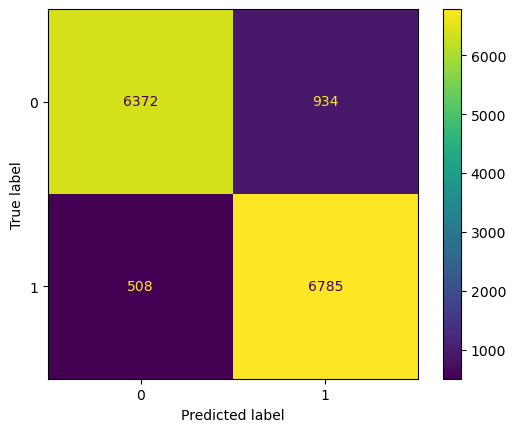

In [243]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_train, class_pred)
plt.show()

# TESTING OF OUR MODEL

In [244]:
x_train_sca = StandardScaler()
x_train_scaled2 = x_train_sca.fit(x_train)
x_train_scaled2

x_test_scaled = x_train_scaled2.transform(x_test)

x_test_scaled_df = pd.DataFrame(x_test_scaled, columns = x_test.columns)

x_test_scaled_df.head()

,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,year,month
0,-1.450855,-0.185134,-0.172302,-0.224202,-0.183798,-0.132678,-0.147144,-0.082020,-0.063254,1.968686,-1.188420
1,-1.078752,-0.134266,-0.052370,-0.185396,-0.210727,-0.152734,-0.186766,-0.033925,-0.177018,-1.221669,1.360639
2,0.087172,-0.248115,-0.235124,-0.246214,-0.211662,-0.243342,-0.243894,-0.224971,-0.177018,-0.158217,-1.471649
3,-1.078752,-0.170559,-0.114746,-0.223642,-0.206406,-0.153524,-0.145404,-0.162902,-0.177018,-0.158217,-0.905191
4,0.111978,-0.246676,-0.235380,-0.246245,-0.211662,-0.237910,-0.237407,-0.222831,-0.177018,0.905234,-1.188420


# Application of the pca into the test model

In [245]:
x_test_pca = pca_2.transform(x_test_scaled_df)

x_test_pca.shape

(3650, 3)

In [246]:
x_test_pca_df = pd.DataFrame({"pca_1" : x_test_pca[:, 0],
                               "pca_2" : x_test_pca[:, 1],
                               "pca_3" : x_test_pca[:, 2]
                              })
x_test_pca_df.head()

,pca_1,pca_2,pca_3
0,-0.264240,-2.445463,-0.370579
1,-0.338724,1.544957,-1.169430
2,-0.640827,-0.998679,-0.447621
3,-0.377474,-0.811103,-1.192531
4,-0.626083,-1.454634,0.231478


# Making the plot

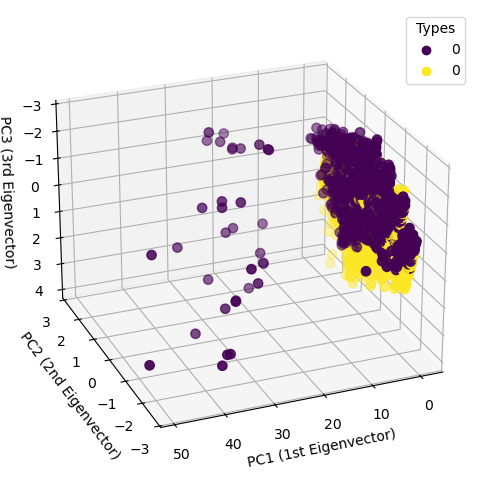

In [247]:
fig = plt.figure(1, figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d", elev=-155, azim=112)
# scatter plot of eigen vectors
sctr = ax.scatter(x_test_pca[:, 0], x_test_pca[:, 1], x_test_pca[:, 2],
           c = y_test, s=45,)
ax.legend(sctr.legend_elements()[0], y_test,
          loc="upper right", title="Types")

ax.set_xlabel("PC1 (1st Eigenvector)")
#ax.xaxis.set_ticklabels([])
ax.set_ylabel("PC2 (2nd Eigenvector)")
#ax.yaxis.set_ticklabels([])
ax.set_zlabel("PC3 (3rd Eigenvector)")

plt.show()

In [248]:
class_y_pred = avocado_model2.predict(x_test_pca_df)
class_y_pred

array([0, 0, 1, ..., 0, 1, 1])

In [249]:
from sklearn import metrics
print(metrics.classification_report(y_test, class_y_pred))

              precision    recall  f1-score   support

           0       0.93      0.86      0.89      1820
           1       0.87      0.94      0.90      1830

    accuracy                           0.90      3650
   macro avg       0.90      0.90      0.90      3650
weighted avg       0.90      0.90      0.90      3650



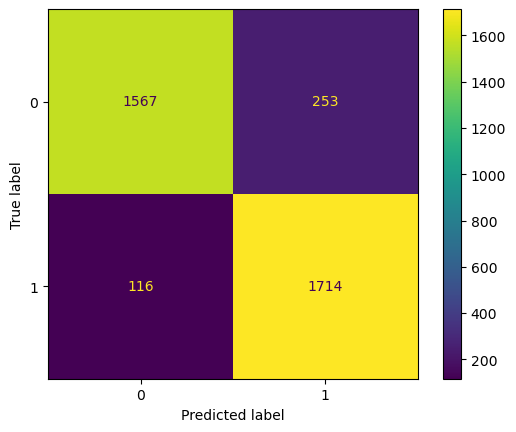

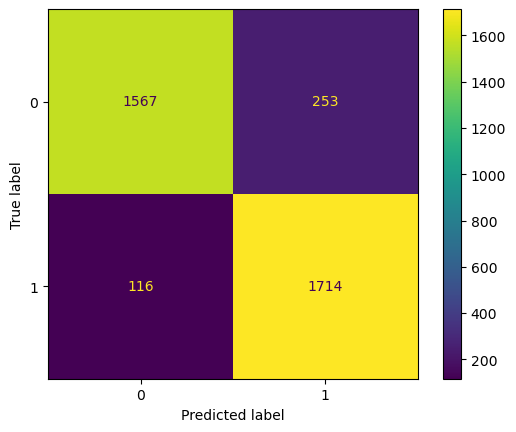

In [250]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pylab as plt

ConfusionMatrixDisplay.from_predictions(y_test, class_y_pred).plot()
plt.show()

In [251]:
x_avocado =avocado_3
y_avocado = avocado3["type"]

In [252]:
import statsmodels.api as sm

X_sm = sm.add_constant(x_avocado)

model_train = sm.Logit(y_avocado, X_sm).fit_regularized(L1_wt=1, alpha=0.1, maxiter=1000) #Lasso regularization

print(model_train.summary())

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log


Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.155021180571402
            Iterations: 225
            Function evaluations: 273
            Gradient evaluations: 225
                           Logit Regression Results                           
Dep. Variable:                   type   No. Observations:                18249
Model:                          Logit   Df Residuals:                    18237
Method:                           MLE   Df Model:                           11
Date:                Mon, 20 Apr 2026   Pseudo R-squ.:                  0.7765
Time:                        01:38:34   Log-Likelihood:                -2827.3
converged:                       True   LL-Null:                       -12649.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 8 out of 12 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp


# ✅ Model Comparison: With PCA vs Without PCA

In this analysis, I compared the performance of models built using the original features and those built after applying Principal Component Analysis (PCA).

The model trained on the original features (without PCA) performed better. This is because it retained all the available information in the dataset, which helped improve predictive performance.

Although PCA was useful in reducing dimensionality and addressing multicollinearity by transforming correlated variables into independent components, it also resulted in some loss of information. This loss likely affected the model’s ability to make accurate predictions.

Based on the evaluation metrics, the non-PCA model was selected as the better model, as it achieved higher performance and provided more reliable results for this task.

# 🔍 Model Performance (With PCA)

The Logistic Regression model trained on PCA-transformed features achieved a slightly lower accuracy compared to the model without PCA. This indicates that while the model is still able to classify avocado types reasonably well, its predictive performance decreased after dimensionality reduction.

The precision, recall, and F1-scores for both classes remain fairly balanced:

Class 0 (e.g., Conventional)
Class 1 (e.g., Organic)

👉 This shows that the model still performs consistently across both classes, but with a slight reduction in overall effectiveness.

⸻

# 🔲 Confusion Matrix Interpretation

The confusion matrix still shows a good number of correct predictions along the diagonal, but with slightly more misclassifications compared to the non-PCA model.

Many conventional avocados are correctly classified
Many organic avocados are correctly classified
However, misclassifications are slightly higher

👉 This suggests that while the model can still distinguish between avocado types, its accuracy has been slightly affected.

# 📌 Final Conclusion (With PCA)

In this notebook, Logistic Regression was also applied after reducing the dataset using Principal Component Analysis (PCA). While PCA helped reduce dimensionality and remove multicollinearity, the model achieved slightly lower accuracy compared to the model trained on the original features.

Although the evaluation metrics (precision, recall, and F1-score) remain relatively balanced, the small drop in performance indicates that some important information may have been lost during the transformation process.

The confusion matrix further supports this, showing a slight increase in misclassifications.

In conclusion, while PCA simplifies the dataset and can be useful in handling high-dimensional data, it did not improve model performance in this case. The model without PCA remains the better choice for classifying avocado types.